# Supervised Metric Learning Baseline

This notebook establishes a verification-oriented supervised metric-learning baseline on QUWI.

## Purpose

The previous supervised baselines optimized writer classification. This experiment instead optimizes the embedding space directly so that handwriting samples from the same writer have higher cosine similarity and samples from different writers have lower similarity.

## Controlled training protocol

- Use development-training writers only
- Keep validation and official-test writers completely unseen during training
- Use Arabic page 1 and page 2 samples for the initial controlled metric-learning baseline
- Treat page 1 and page 2 from the same writer as a genuine training pair
- Construct deterministic impostor pairs from different development writers
- Start from an ImageNet-pretrained ResNet-18
- Fine-tune layer 4 while keeping the earlier backbone frozen
- Keep BatchNorm running statistics frozen
- Optimize a cosine-based contrastive objective
- Evaluate the learned 512-dimensional normalized embeddings using the fixed writer-disjoint verification protocol

## Motivation

Using the same Arabic development condition as the earlier supervised baseline makes this experiment a controlled comparison between classification-oriented and verification-oriented training.

This notebook is therefore a bridge baseline. More advanced writer-aware sampling, self-supervised learning, and script-invariant representation learning will be investigated in later stages.

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18

from handwriting_cross_script_research import QUWIDataset

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    PROJECT_ROOT / "pyproject.toml"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "pyproject.toml").exists()

IMAGE_DIR = (
    Path.home()
    / "Documents"
    / "Handwriting"
    / "QUWI"
    / "extracted"
    / "images"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "splits"
    / "quwi_writer_disjoint_split_seed42.csv"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "supervised_metric_learning"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "supervised_metric_learning"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

split_df = pd.read_csv(
    SPLIT_PATH
)

development_df = split_df[
    split_df["experiment_split"]
    == "development_train"
].copy()

validation_df = split_df[
    split_df["experiment_split"]
    == "validation"
].copy()

test_df = split_df[
    split_df["experiment_split"]
    == "official_test"
].copy()

print("Project root:", PROJECT_ROOT)
print("Image directory exists:", IMAGE_DIR.exists())
print("Development images:", len(development_df))
print("Development writers:", development_df["writer"].nunique())
print("Validation writers:", validation_df["writer"].nunique())
print("Official-test writers:", test_df["writer"].nunique())
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

assert len(development_df) == 904
assert development_df["writer"].nunique() == 226
assert validation_df["writer"].nunique() == 56
assert test_df["writer"].nunique() == 193

Project root: /home/arijit/Documents/handwriting-cross-script-research
Image directory exists: True
Development images: 904
Development writers: 226
Validation writers: 56
Official-test writers: 193
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
arabic_page1_df = (
    development_df[
        development_df["page_id"] == 1
    ][
        [
            "writer",
            "filename",
            "page_id",
            "language",
            "same_text",
        ]
    ]
    .sort_values("writer")
    .reset_index(drop=True)
)

arabic_page2_df = (
    development_df[
        development_df["page_id"] == 2
    ][
        [
            "writer",
            "filename",
            "page_id",
            "language",
            "same_text",
        ]
    ]
    .sort_values("writer")
    .reset_index(drop=True)
)

writers = (
    arabic_page1_df["writer"]
    .to_numpy()
)

assert np.array_equal(
    writers,
    arabic_page2_df["writer"].to_numpy(),
)

genuine_pairs_df = pd.DataFrame(
    {
        "filename_a": arabic_page1_df[
            "filename"
        ].to_numpy(),
        "filename_b": arabic_page2_df[
            "filename"
        ].to_numpy(),
        "writer_a": writers,
        "writer_b": writers,
        "pair_label": 1,
        "pair_type": "genuine",
    }
)

negative_writer_indices = np.roll(
    np.arange(len(writers)),
    -1,
)

impostor_pairs_df = pd.DataFrame(
    {
        "filename_a": arabic_page1_df[
            "filename"
        ].to_numpy(),
        "filename_b": arabic_page2_df[
            "filename"
        ].to_numpy()[
            negative_writer_indices
        ],
        "writer_a": writers,
        "writer_b": writers[
            negative_writer_indices
        ],
        "pair_label": 0,
        "pair_type": "impostor",
    }
)

training_pairs_df = (
    pd.concat(
        [
            genuine_pairs_df,
            impostor_pairs_df,
        ],
        ignore_index=True,
    )
    .sample(
        frac=1.0,
        random_state=SEED,
    )
    .reset_index(drop=True)
)

print(
    "Arabic page-1 images:",
    len(arabic_page1_df),
)

print(
    "Arabic page-2 images:",
    len(arabic_page2_df),
)

print(
    "Training pairs:",
    len(training_pairs_df),
)

print(
    "Pair labels:",
    training_pairs_df[
        "pair_label"
    ].value_counts().sort_index().to_dict(),
)

print(
    "Genuine writer mismatches:",
    (
        genuine_pairs_df["writer_a"]
        != genuine_pairs_df["writer_b"]
    ).sum(),
)

print(
    "Impostor writer matches:",
    (
        impostor_pairs_df["writer_a"]
        == impostor_pairs_df["writer_b"]
    ).sum(),
)

print(
    "Unique anchor writers:",
    training_pairs_df[
        "writer_a"
    ].nunique(),
)

assert len(arabic_page1_df) == 226
assert len(arabic_page2_df) == 226
assert len(training_pairs_df) == 452
assert training_pairs_df["pair_label"].value_counts().to_dict() == {
    1: 226,
    0: 226,
}
assert not (
    impostor_pairs_df["writer_a"]
    == impostor_pairs_df["writer_b"]
).any()

Arabic page-1 images: 226
Arabic page-2 images: 226
Training pairs: 452
Pair labels: {0: 226, 1: 226}
Genuine writer mismatches: 0
Impostor writer matches: 0
Unique anchor writers: 226


In [4]:
from handwriting_cross_script_research import load_image_tensor


class QUWIPairDataset(Dataset):
    def __init__(
        self,
        pair_dataframe,
        image_dir,
    ):
        self.pairs = (
            pair_dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.image_dir = Path(
            image_dir
        )

    def __len__(self):
        return len(
            self.pairs
        )

    def __getitem__(
        self,
        index,
    ):
        row = self.pairs.iloc[
            index
        ]

        image_a, _ = load_image_tensor(
            self.image_dir
            / row["filename_a"]
        )

        image_b, _ = load_image_tensor(
            self.image_dir
            / row["filename_b"]
        )

        return {
            "image_a": image_a,
            "image_b": image_b,
            "pair_label": torch.tensor(
                row["pair_label"],
                dtype=torch.float32,
            ),
            "writer_a": int(
                row["writer_a"]
            ),
            "writer_b": int(
                row["writer_b"]
            ),
            "filename_a": row[
                "filename_a"
            ],
            "filename_b": row[
                "filename_b"
            ],
        }


BATCH_SIZE = 8
NUM_WORKERS = 0

training_pair_dataset = QUWIPairDataset(
    training_pairs_df,
    IMAGE_DIR,
)

training_generator = (
    torch.Generator()
    .manual_seed(SEED)
)

training_pair_loader = DataLoader(
    training_pair_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=training_generator,
)

pair_batch = next(
    iter(training_pair_loader)
)

print(
    "Training pair dataset:",
    len(training_pair_dataset),
)

print(
    "Training batches:",
    len(training_pair_loader),
)

print(
    "Image A shape:",
    pair_batch["image_a"].shape,
)

print(
    "Image B shape:",
    pair_batch["image_b"].shape,
)

print(
    "Batch labels:",
    pair_batch[
        "pair_label"
    ].tolist(),
)

print(
    "Batch genuine pairs:",
    int(
        pair_batch[
            "pair_label"
        ].sum().item()
    ),
)

assert len(
    training_pair_dataset
) == 452

assert pair_batch[
    "image_a"
].shape == (
    8,
    3,
    384,
    384,
)

assert pair_batch[
    "image_b"
].shape == (
    8,
    3,
    384,
    384,
)

assert set(
    pair_batch[
        "pair_label"
    ].tolist()
).issubset(
    {
        0.0,
        1.0,
    }
)

Training pair dataset: 452
Training batches: 57
Image A shape: torch.Size([8, 3, 384, 384])
Image B shape: torch.Size([8, 3, 384, 384])
Batch labels: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0]
Batch genuine pairs: 6


In [5]:
IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406,
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225,
)


class MetricEmbeddingModel(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        backbone.fc = nn.Identity()

        self.feature_extractor = backbone

        self.register_buffer(
            "normalization_mean",
            torch.tensor(
                IMAGENET_MEAN
            ).view(
                1,
                3,
                1,
                1,
            ),
        )

        self.register_buffer(
            "normalization_std",
            torch.tensor(
                IMAGENET_STD
            ).view(
                1,
                3,
                1,
                1,
            ),
        )

        for parameter in (
            self.feature_extractor
            .parameters()
        ):
            parameter.requires_grad = False

        for parameter in (
            self.feature_extractor
            .layer4
            .parameters()
        ):
            parameter.requires_grad = True

    def train(
        self,
        mode=True,
    ):
        super().train(mode)

        self.feature_extractor.eval()

        return self

    def forward(
        self,
        images,
    ):
        images = (
            images
            - self.normalization_mean
        ) / self.normalization_std

        features = (
            self.feature_extractor(
                images
            )
        )

        embeddings = F.normalize(
            features,
            p=2,
            dim=1,
        )

        return embeddings


metric_model = (
    MetricEmbeddingModel()
    .to(DEVICE)
)

metric_model.train()

trainable_parameters = sum(
    parameter.numel()
    for parameter in metric_model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in metric_model.parameters()
)

frozen_parameters = (
    total_parameters
    - trainable_parameters
)

LOSS_MARGIN = 0.5

criterion = nn.CosineEmbeddingLoss(
    margin=LOSS_MARGIN,
)

optimizer = torch.optim.AdamW(
    metric_model.feature_extractor.layer4.parameters(),
    lr=1e-5,
    weight_decay=1e-4,
)

sample_a = pair_batch[
    "image_a"
].to(
    DEVICE,
    non_blocking=True,
)

sample_b = pair_batch[
    "image_b"
].to(
    DEVICE,
    non_blocking=True,
)

sample_labels = pair_batch[
    "pair_label"
].to(
    DEVICE,
    non_blocking=True,
)

cosine_targets = torch.where(
    sample_labels == 1,
    torch.ones_like(
        sample_labels
    ),
    -torch.ones_like(
        sample_labels
    ),
)

with torch.no_grad():
    embedding_a = metric_model(
        sample_a
    )

    embedding_b = metric_model(
        sample_b
    )

    initial_loss = criterion(
        embedding_a,
        embedding_b,
        cosine_targets,
    )

print(
    "Total parameters:",
    total_parameters,
)

print(
    "Trainable parameters:",
    trainable_parameters,
)

print(
    "Frozen parameters:",
    frozen_parameters,
)

print(
    "Embedding A shape:",
    embedding_a.shape,
)

print(
    "Embedding B shape:",
    embedding_b.shape,
)

print(
    "Mean embedding norm A:",
    round(
        embedding_a.norm(
            dim=1
        ).mean().item(),
        6,
    ),
)

print(
    "Mean embedding norm B:",
    round(
        embedding_b.norm(
            dim=1
        ).mean().item(),
        6,
    ),
)

print(
    "Cosine loss margin:",
    LOSS_MARGIN,
)

print(
    "Initial pair loss:",
    round(
        initial_loss.item(),
        6,
    ),
)

print(
    "Layer4 training flag:",
    metric_model.feature_extractor.layer4.training,
)

assert embedding_a.shape == (
    8,
    512,
)

assert embedding_b.shape == (
    8,
    512,
)

assert (
    metric_model
    .feature_extractor
    .layer4
    .training
    is False
)

Total parameters: 11176512
Trainable parameters: 8393728
Frozen parameters: 2782784
Embedding A shape: torch.Size([8, 512])
Embedding B shape: torch.Size([8, 512])
Mean embedding norm A: 1.0
Mean embedding norm B: 1.0
Cosine loss margin: 0.5
Initial pair loss: 0.137837
Layer4 training flag: False


In [6]:
metric_model.train()
optimizer.zero_grad(
    set_to_none=True
)

batch_a = pair_batch[
    "image_a"
].to(
    DEVICE,
    non_blocking=True,
)

batch_b = pair_batch[
    "image_b"
].to(
    DEVICE,
    non_blocking=True,
)

batch_labels = pair_batch[
    "pair_label"
].to(
    DEVICE,
    non_blocking=True,
)

targets = torch.where(
    batch_labels == 1,
    torch.ones_like(
        batch_labels
    ),
    -torch.ones_like(
        batch_labels
    ),
)

bn_layer = (
    metric_model
    .feature_extractor
    .layer4[0]
    .bn1
)

bn_mean_before = (
    bn_layer.running_mean
    .detach()
    .clone()
)

embedding_a = metric_model(
    batch_a
)

embedding_b = metric_model(
    batch_b
)

smoke_loss = criterion(
    embedding_a,
    embedding_b,
    targets,
)

smoke_loss.backward()

layer4_grad_norm = torch.sqrt(
    sum(
        parameter.grad.detach().norm() ** 2
        for parameter in (
            metric_model
            .feature_extractor
            .layer4
            .parameters()
        )
        if parameter.grad is not None
    )
)

early_backbone_gradients = sum(
    parameter.grad is not None
    for name, parameter in (
        metric_model
        .feature_extractor
        .named_parameters()
    )
    if not name.startswith(
        "layer4."
    )
)

bn_mean_after = (
    bn_layer.running_mean
    .detach()
    .clone()
)

print(
    "Smoke loss:",
    round(
        smoke_loss.item(),
        6,
    ),
)

print(
    "Layer4 gradient norm:",
    round(
        layer4_grad_norm.item(),
        6,
    ),
)

print(
    "Finite layer4 gradient:",
    torch.isfinite(
        layer4_grad_norm
    ).item(),
)

print(
    "Early-backbone parameters with gradients:",
    early_backbone_gradients,
)

print(
    "BatchNorm running mean unchanged:",
    torch.equal(
        bn_mean_before,
        bn_mean_after,
    ),
)

optimizer.zero_grad(
    set_to_none=True
)

assert torch.isfinite(
    layer4_grad_norm
)

assert layer4_grad_norm.item() > 0

assert early_backbone_gradients == 0

assert torch.equal(
    bn_mean_before,
    bn_mean_after,
)

Smoke loss: 0.137837
Layer4 gradient norm: 0.42816
Finite layer4 gradient: True
Early-backbone parameters with gradients: 0
BatchNorm running mean unchanged: True


In [7]:
VALIDATION_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_validation_verification_pairs.csv"
)

validation_pairs_df = pd.read_csv(
    VALIDATION_PAIR_PATH
)

validation_dataset = QUWIDataset(
    metadata=validation_df,
    image_dir=IMAGE_DIR,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


@torch.inference_mode()
def extract_embeddings(
    model,
    loader,
):
    model.eval()

    filenames = []
    embedding_batches = []

    for batch in loader:
        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        embeddings = model(
            images
        )

        embedding_batches.append(
            embeddings.cpu()
        )

        filenames.extend(
            batch["filename"]
        )

    return (
        filenames,
        torch.cat(
            embedding_batches,
            dim=0,
        ),
    )


def score_pairs(
    pair_df,
    filenames,
    embeddings,
):
    filename_to_index = {
        filename: index
        for index, filename
        in enumerate(filenames)
    }

    index_a = torch.tensor(
        [
            filename_to_index[
                filename
            ]
            for filename
            in pair_df[
                "filename_a"
            ]
        ],
        dtype=torch.long,
    )

    index_b = torch.tensor(
        [
            filename_to_index[
                filename
            ]
            for filename
            in pair_df[
                "filename_b"
            ]
        ],
        dtype=torch.long,
    )

    return (
        embeddings[index_a]
        * embeddings[index_b]
    ).sum(
        dim=1
    ).numpy()


def verification_metrics(
    labels,
    scores,
):
    auc = roc_auc_score(
        labels,
        scores,
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1,
    )

    fnr = 1.0 - tpr

    difference = (
        fpr - fnr
    )

    eer = np.interp(
        0.0,
        difference,
        fpr,
    )

    threshold = np.interp(
        0.0,
        difference,
        thresholds,
    )

    return {
        "roc_auc": float(auc),
        "eer": float(eer),
        "eer_percent": float(
            eer * 100
        ),
        "eer_threshold": float(
            threshold
        ),
    }


validation_filenames, epoch0_embeddings = (
    extract_embeddings(
        metric_model,
        validation_loader,
    )
)

epoch0_scores = score_pairs(
    validation_pairs_df,
    validation_filenames,
    epoch0_embeddings,
)

epoch0_metrics = verification_metrics(
    validation_pairs_df[
        "pair_label"
    ].to_numpy(),
    epoch0_scores,
)

print(
    "Validation embeddings:",
    epoch0_embeddings.shape,
)

print(
    "Validation scores:",
    len(epoch0_scores),
)

print(
    "Epoch-0 ROC-AUC:",
    round(
        epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Epoch-0 EER:",
    round(
        epoch0_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Epoch-0 EER threshold:",
    round(
        epoch0_metrics[
            "eer_threshold"
        ],
        6,
    ),
)

print(
    "All scores finite:",
    np.isfinite(
        epoch0_scores
    ).all(),
)

assert epoch0_embeddings.shape == (
    224,
    512,
)

assert len(
    epoch0_scores
) == 18_816

assert np.isfinite(
    epoch0_scores
).all()

Validation embeddings: torch.Size([224, 512])
Validation scores: 18816
Epoch-0 ROC-AUC: 0.612379
Epoch-0 EER: 43.1548 %
Epoch-0 EER threshold: 0.939745
All scores finite: True


In [8]:
MAX_GRAD_NORM = 5.0
EPOCHS = 10

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "resnet18_metric_learning_best.pt"
)


def train_metric_epoch(
    model,
    loader,
    optimizer,
    criterion,
):
    model.train()

    total_loss = 0.0
    total_pairs = 0
    genuine_similarities = []
    impostor_similarities = []
    gradient_norms = []
    skipped_steps = 0

    for batch in loader:
        image_a = batch[
            "image_a"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        image_b = batch[
            "image_b"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        labels = batch[
            "pair_label"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        targets = torch.where(
            labels == 1,
            torch.ones_like(
                labels
            ),
            -torch.ones_like(
                labels
            ),
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        embedding_a = model(
            image_a
        )

        embedding_b = model(
            image_b
        )

        loss = criterion(
            embedding_a,
            embedding_b,
            targets,
        )

        loss.backward()

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                model
                .feature_extractor
                .layer4
                .parameters(),
                max_norm=MAX_GRAD_NORM,
            )
        )

        if torch.isfinite(
            gradient_norm
        ):
            optimizer.step()
        else:
            skipped_steps += 1

        similarities = (
            embedding_a
            * embedding_b
        ).sum(
            dim=1
        ).detach()

        genuine_mask = (
            labels == 1
        )

        impostor_mask = (
            labels == 0
        )

        genuine_similarities.extend(
            similarities[
                genuine_mask
            ].cpu().tolist()
        )

        impostor_similarities.extend(
            similarities[
                impostor_mask
            ].cpu().tolist()
        )

        gradient_norms.append(
            float(
                gradient_norm.detach().cpu()
            )
        )

        batch_size = len(
            labels
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        total_pairs += batch_size

    return {
        "loss": (
            total_loss
            / total_pairs
        ),
        "genuine_similarity": float(
            np.mean(
                genuine_similarities
            )
        ),
        "impostor_similarity": float(
            np.mean(
                impostor_similarities
            )
        ),
        "training_score_gap": float(
            np.mean(
                genuine_similarities
            )
            - np.mean(
                impostor_similarities
            )
        ),
        "mean_gradient_norm": float(
            np.mean(
                gradient_norms
            )
        ),
        "max_gradient_norm": float(
            np.max(
                gradient_norms
            )
        ),
        "skipped_steps": int(
            skipped_steps
        ),
    }


def evaluate_validation(
    model,
):
    filenames, embeddings = (
        extract_embeddings(
            model,
            validation_loader,
        )
    )

    scores = score_pairs(
        validation_pairs_df,
        filenames,
        embeddings,
    )

    metrics = verification_metrics(
        validation_pairs_df[
            "pair_label"
        ].to_numpy(),
        scores,
    )

    return (
        metrics,
        embeddings,
        scores,
    )


torch.save(
    {
        "epoch": 0,
        "model_state_dict": (
            metric_model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "validation_metrics": (
            epoch0_metrics
        ),
        "configuration": {
            "seed": SEED,
            "loss": (
                "CosineEmbeddingLoss"
            ),
            "margin": LOSS_MARGIN,
            "learning_rate": 1e-5,
            "weight_decay": 1e-4,
            "max_gradient_norm": (
                MAX_GRAD_NORM
            ),
            "training_pairs": len(
                training_pairs_df
            ),
        },
    },
    BEST_CHECKPOINT_PATH,
)

print(
    "Epoch-0 checkpoint saved:",
    BEST_CHECKPOINT_PATH.exists(),
)

print(
    "Initial best validation AUC:",
    round(
        epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Initial best validation EER:",
    round(
        epoch0_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

Epoch-0 checkpoint saved: True
Initial best validation AUC: 0.612379
Initial best validation EER: 43.1548 %


In [9]:
history_rows = [
    {
        "epoch": 0,
        "train_loss": np.nan,
        "train_genuine_similarity": np.nan,
        "train_impostor_similarity": np.nan,
        "train_score_gap": np.nan,
        "mean_gradient_norm": np.nan,
        "max_gradient_norm": np.nan,
        "skipped_steps": 0,
        "validation_roc_auc": (
            epoch0_metrics[
                "roc_auc"
            ]
        ),
        "validation_eer_percent": (
            epoch0_metrics[
                "eer_percent"
            ]
        ),
        "validation_eer_threshold": (
            epoch0_metrics[
                "eer_threshold"
            ]
        ),
    }
]

best_epoch = 0

best_validation_auc = (
    epoch0_metrics[
        "roc_auc"
    ]
)

best_validation_eer = (
    epoch0_metrics[
        "eer_percent"
    ]
)

for epoch in range(
    1,
    EPOCHS + 1,
):
    train_metrics = train_metric_epoch(
        metric_model,
        training_pair_loader,
        optimizer,
        criterion,
    )

    (
        validation_metrics,
        _,
        _,
    ) = evaluate_validation(
        metric_model
    )

    history_rows.append(
        {
            "epoch": epoch,
            "train_loss": train_metrics[
                "loss"
            ],
            "train_genuine_similarity": train_metrics[
                "genuine_similarity"
            ],
            "train_impostor_similarity": train_metrics[
                "impostor_similarity"
            ],
            "train_score_gap": train_metrics[
                "training_score_gap"
            ],
            "mean_gradient_norm": train_metrics[
                "mean_gradient_norm"
            ],
            "max_gradient_norm": train_metrics[
                "max_gradient_norm"
            ],
            "skipped_steps": train_metrics[
                "skipped_steps"
            ],
            "validation_roc_auc": validation_metrics[
                "roc_auc"
            ],
            "validation_eer_percent": validation_metrics[
                "eer_percent"
            ],
            "validation_eer_threshold": validation_metrics[
                "eer_threshold"
            ],
        }
    )

    auc_improved = (
        validation_metrics[
            "roc_auc"
        ]
        > best_validation_auc
        + 1e-12
    )

    auc_tied = np.isclose(
        validation_metrics[
            "roc_auc"
        ],
        best_validation_auc,
        atol=1e-12,
        rtol=0.0,
    )

    eer_improved_on_tie = (
        auc_tied
        and validation_metrics[
            "eer_percent"
        ]
        < best_validation_eer
    )

    if (
        auc_improved
        or eer_improved_on_tie
    ):
        best_epoch = epoch

        best_validation_auc = (
            validation_metrics[
                "roc_auc"
            ]
        )

        best_validation_eer = (
            validation_metrics[
                "eer_percent"
            ]
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": (
                    metric_model.state_dict()
                ),
                "optimizer_state_dict": (
                    optimizer.state_dict()
                ),
                "training_metrics": (
                    train_metrics
                ),
                "validation_metrics": (
                    validation_metrics
                ),
                "configuration": {
                    "seed": SEED,
                    "loss": (
                        "CosineEmbeddingLoss"
                    ),
                    "margin": LOSS_MARGIN,
                    "learning_rate": 1e-5,
                    "weight_decay": 1e-4,
                    "max_gradient_norm": (
                        MAX_GRAD_NORM
                    ),
                    "training_pairs": len(
                        training_pairs_df
                    ),
                },
            },
            BEST_CHECKPOINT_PATH,
        )

    print(
        f"Epoch {epoch:02d} | "
        f"loss {train_metrics['loss']:.4f} | "
        f"genuine {train_metrics['genuine_similarity']:.4f} | "
        f"impostor {train_metrics['impostor_similarity']:.4f} | "
        f"gap {train_metrics['training_score_gap']:.4f} | "
        f"val AUC {validation_metrics['roc_auc']:.4f} | "
        f"val EER {validation_metrics['eer_percent']:.2f}% | "
        f"grad {train_metrics['mean_gradient_norm']:.4f} | "
        f"skipped {train_metrics['skipped_steps']}"
    )

training_history_df = pd.DataFrame(
    history_rows
)

print()
print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation AUC:",
    round(
        best_validation_auc,
        6,
    ),
)

print(
    "Best validation EER:",
    round(
        best_validation_eer,
        4,
    ),
    "%",
)

print(
    "Best checkpoint exists:",
    BEST_CHECKPOINT_PATH.exists(),
)

print(
    "Total skipped optimizer steps:",
    int(
        training_history_df[
            "skipped_steps"
        ].sum()
    ),
)

Epoch 01 | loss 0.2360 | genuine 0.9266 | impostor 0.8986 | gap 0.0280 | val AUC 0.6373 | val EER 40.18% | grad 0.6864 | skipped 0
Epoch 02 | loss 0.2107 | genuine 0.8637 | impostor 0.7842 | gap 0.0795 | val AUC 0.6578 | val EER 38.39% | grad 1.3942 | skipped 0
Epoch 03 | loss 0.1786 | genuine 0.8025 | impostor 0.6445 | gap 0.1580 | val AUC 0.7036 | val EER 36.01% | grad 2.0144 | skipped 0
Epoch 04 | loss 0.1558 | genuine 0.8130 | impostor 0.5931 | gap 0.2198 | val AUC 0.7043 | val EER 35.24% | grad 2.1142 | skipped 0
Epoch 05 | loss 0.1417 | genuine 0.8168 | impostor 0.5596 | gap 0.2572 | val AUC 0.7133 | val EER 34.52% | grad 2.3027 | skipped 0
Epoch 06 | loss 0.1287 | genuine 0.8342 | impostor 0.5484 | gap 0.2858 | val AUC 0.7194 | val EER 34.86% | grad 2.2265 | skipped 0
Epoch 07 | loss 0.1176 | genuine 0.8323 | impostor 0.5121 | gap 0.3202 | val AUC 0.7287 | val EER 33.63% | grad 2.4740 | skipped 0
Epoch 08 | loss 0.1102 | genuine 0.8506 | impostor 0.5177 | gap 0.3329 | val AUC 0.

In [10]:
best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

best_metric_model = (
    MetricEmbeddingModel()
    .to(DEVICE)
)

best_metric_model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

best_metric_model.eval()

TEST_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_official_test_verification_pairs.csv"
)

test_pairs_df = pd.read_csv(
    TEST_PAIR_PATH
)

test_dataset = QUWIDataset(
    metadata=test_df,
    image_dir=IMAGE_DIR,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

best_validation_filenames, best_validation_embeddings = (
    extract_embeddings(
        best_metric_model,
        validation_loader,
    )
)

best_test_filenames, best_test_embeddings = (
    extract_embeddings(
        best_metric_model,
        test_loader,
    )
)

best_validation_scores = score_pairs(
    validation_pairs_df,
    best_validation_filenames,
    best_validation_embeddings,
)

best_test_scores = score_pairs(
    test_pairs_df,
    best_test_filenames,
    best_test_embeddings,
)

best_validation_metrics = verification_metrics(
    validation_pairs_df[
        "pair_label"
    ].to_numpy(),
    best_validation_scores,
)

best_test_metrics = verification_metrics(
    test_pairs_df[
        "pair_label"
    ].to_numpy(),
    best_test_scores,
)

print(
    "Loaded checkpoint epoch:",
    best_checkpoint["epoch"],
)

print(
    "Validation embeddings:",
    best_validation_embeddings.shape,
)

print(
    "Official-test embeddings:",
    best_test_embeddings.shape,
)

print(
    "Best validation ROC-AUC:",
    round(
        best_validation_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Best validation EER:",
    round(
        best_validation_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Official-test ROC-AUC:",
    round(
        best_test_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Official-test EER:",
    round(
        best_test_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Validation scores finite:",
    np.isfinite(
        best_validation_scores
    ).all(),
)

print(
    "Official-test scores finite:",
    np.isfinite(
        best_test_scores
    ).all(),
)

assert best_checkpoint["epoch"] == 8
assert best_validation_embeddings.shape == (
    224,
    512,
)
assert best_test_embeddings.shape == (
    772,
    512,
)
assert len(best_validation_scores) == 18_816
assert len(best_test_scores) == 223_494

Loaded checkpoint epoch: 8
Validation embeddings: torch.Size([224, 512])
Official-test embeddings: torch.Size([772, 512])
Best validation ROC-AUC: 0.738648
Best validation EER: 32.6948 %
Official-test ROC-AUC: 0.758257
Official-test EER: 31.5199 %
Validation scores finite: True
Official-test scores finite: True


In [11]:
def evaluate_conditions(
    pair_df,
    scores,
    split_name,
):
    scored_df = pair_df.copy()

    scored_df[
        "metric_cosine_score"
    ] = scores

    rows = []

    aggregate = verification_metrics(
        scored_df[
            "pair_label"
        ].to_numpy(),
        scored_df[
            "metric_cosine_score"
        ].to_numpy(),
    )

    rows.append(
        {
            "experiment_split": split_name,
            "condition_id": "all_conditions",
            **aggregate,
        }
    )

    for condition_id, condition_df in scored_df.groupby(
        "condition_id",
        sort=False,
    ):
        metrics = verification_metrics(
            condition_df[
                "pair_label"
            ].to_numpy(),
            condition_df[
                "metric_cosine_score"
            ].to_numpy(),
        )

        rows.append(
            {
                "experiment_split": split_name,
                "condition_id": condition_id,
                **metrics,
            }
        )

    return pd.DataFrame(
        rows
    )


metric_condition_results_df = pd.concat(
    [
        evaluate_conditions(
            validation_pairs_df,
            best_validation_scores,
            "validation",
        ),
        evaluate_conditions(
            test_pairs_df,
            best_test_scores,
            "official_test",
        ),
    ],
    ignore_index=True,
)

display(
    metric_condition_results_df[
        [
            "experiment_split",
            "condition_id",
            "roc_auc",
            "eer_percent",
            "eer_threshold",
        ]
    ].round(4)
)

BASELINE_METRICS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "writer_disjoint_baseline_verification"
    / "verification_metrics.csv"
)

baseline_metrics_df = pd.read_csv(
    BASELINE_METRICS_PATH
)

baseline_finetuned_df = baseline_metrics_df[
    (
        baseline_metrics_df[
            "model"
        ] == "layer4_finetuned"
    )
    & (
        baseline_metrics_df[
            "condition_id"
        ] == "all_conditions"
    )
][
    [
        "experiment_split",
        "roc_auc",
        "eer_percent",
    ]
].copy()

metric_aggregate_df = (
    metric_condition_results_df[
        metric_condition_results_df[
            "condition_id"
        ] == "all_conditions"
    ][
        [
            "experiment_split",
            "roc_auc",
            "eer_percent",
        ]
    ]
    .copy()
)

comparison_df = baseline_finetuned_df.merge(
    metric_aggregate_df,
    on="experiment_split",
    suffixes=(
        "_classification",
        "_metric",
    ),
)

comparison_df[
    "auc_improvement"
] = (
    comparison_df[
        "roc_auc_metric"
    ]
    - comparison_df[
        "roc_auc_classification"
    ]
)

comparison_df[
    "eer_change_points"
] = (
    comparison_df[
        "eer_percent_metric"
    ]
    - comparison_df[
        "eer_percent_classification"
    ]
)

display(
    comparison_df.round(4)
)

assert len(
    metric_condition_results_df
) == 14

assert len(
    comparison_df
) == 2

,experiment_split,condition_id,roc_auc,eer_percent,eer_threshold
0,validation,all_conditions,0.7386,32.6948,0.6520
1,validation,arabic_variable_same,0.8604,21.4286,0.7129
2,validation,english_variable_same,0.8118,25.9091,0.7307
3,validation,cross_variable_variable,0.6931,35.7143,0.6161
4,validation,cross_variable_same,0.6848,39.2532,0.6155
5,validation,cross_same_variable,0.6969,35.7143,0.6065
6,validation,cross_same_same,0.7247,33.9286,0.6412
7,official_test,all_conditions,0.7583,31.5199,0.6514
8,official_test,arabic_variable_same,0.8672,20.2073,0.7193
9,official_test,english_variable_same,0.8550,22.2798,0.7571


,experiment_split,roc_auc_classification,eer_percent_classification,roc_auc_metric,eer_percent_metric,auc_improvement,eer_change_points
0,validation,0.6748,36.6721,0.7386,32.6948,0.0638,-3.9773
1,official_test,0.7068,35.1535,0.7583,31.5199,0.0514,-3.6337


In [12]:
condition_metadata_df = (
    validation_pairs_df[
        [
            "condition_id",
            "script_relation",
            "text_relation",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

baseline_condition_df = (
    baseline_metrics_df[
        (
            baseline_metrics_df[
                "model"
            ] == "layer4_finetuned"
        )
        & (
            baseline_metrics_df[
                "condition_id"
            ] != "all_conditions"
        )
    ][
        [
            "experiment_split",
            "condition_id",
            "roc_auc",
            "eer_percent",
        ]
    ]
    .copy()
)

metric_condition_df = (
    metric_condition_results_df[
        metric_condition_results_df[
            "condition_id"
        ] != "all_conditions"
    ][
        [
            "experiment_split",
            "condition_id",
            "roc_auc",
            "eer_percent",
        ]
    ]
    .copy()
)

condition_comparison_df = (
    baseline_condition_df
    .merge(
        metric_condition_df,
        on=[
            "experiment_split",
            "condition_id",
        ],
        suffixes=(
            "_classification",
            "_metric",
        ),
    )
    .merge(
        condition_metadata_df,
        on="condition_id",
        how="left",
    )
)

condition_comparison_df[
    "auc_improvement"
] = (
    condition_comparison_df[
        "roc_auc_metric"
    ]
    - condition_comparison_df[
        "roc_auc_classification"
    ]
)

condition_comparison_df[
    "eer_change_points"
] = (
    condition_comparison_df[
        "eer_percent_metric"
    ]
    - condition_comparison_df[
        "eer_percent_classification"
    ]
)

display(
    condition_comparison_df[
        [
            "experiment_split",
            "condition_id",
            "script_relation",
            "roc_auc_classification",
            "roc_auc_metric",
            "auc_improvement",
            "eer_percent_classification",
            "eer_percent_metric",
            "eer_change_points",
        ]
    ].round(4)
)

print(
    "Metric learning improved AUC conditions:",
    (
        condition_comparison_df[
            "auc_improvement"
        ] > 0
    ).sum(),
    "of",
    len(
        condition_comparison_df
    ),
)

print(
    "Metric learning reduced EER conditions:",
    (
        condition_comparison_df[
            "eer_change_points"
        ] < 0
    ).sum(),
    "of",
    len(
        condition_comparison_df
    ),
)

print(
    "Mean condition AUC improvement:",
    round(
        condition_comparison_df[
            "auc_improvement"
        ].mean(),
        4,
    ),
)

,experiment_split,condition_id,script_relation,roc_auc_classification,roc_auc_metric,auc_improvement,eer_percent_classification,eer_percent_metric,eer_change_points
0,validation,arabic_variable_same,within_arabic,0.7545,0.8604,0.1059,30.3571,21.4286,-8.9286
1,validation,english_variable_same,within_english,0.7156,0.8118,0.0962,33.9286,25.9091,-8.0195
2,validation,cross_variable_variable,cross_script,0.6801,0.6931,0.0130,39.2857,35.7143,-3.5714
3,validation,cross_variable_same,cross_script,0.6119,0.6848,0.0729,44.6429,39.2532,-5.3896
4,validation,cross_same_variable,cross_script,0.6272,0.6969,0.0697,40.4870,35.7143,-4.7727
5,validation,cross_same_same,cross_script,0.6995,0.7247,0.0252,33.7013,33.9286,0.2273
6,official_test,arabic_variable_same,within_arabic,0.8062,0.8672,0.0610,25.3805,20.2073,-5.1733
7,official_test,english_variable_same,within_english,0.7865,0.8550,0.0685,27.4611,22.2798,-5.1813
8,official_test,cross_variable_variable,cross_script,0.6726,0.7150,0.0424,35.7513,34.9984,-0.7529
9,official_test,cross_variable_same,cross_script,0.6304,0.6890,0.0586,39.3782,36.6931,-2.6851


Metric learning improved AUC conditions: 12 of 12
Metric learning reduced EER conditions: 11 of 12
Mean condition AUC improvement: 0.059


In [13]:
classification_family_df = (
    baseline_condition_df
    .merge(
        condition_metadata_df,
        on="condition_id",
        how="left",
    )
)

classification_family_df[
    "training_objective"
] = "classification"

metric_family_df = (
    metric_condition_df
    .merge(
        condition_metadata_df,
        on="condition_id",
        how="left",
    )
)

metric_family_df[
    "training_objective"
] = "metric_learning"

script_family_df = pd.concat(
    [
        classification_family_df,
        metric_family_df,
    ],
    ignore_index=True,
)

script_family_df[
    "script_family"
] = np.where(
    script_family_df[
        "script_relation"
    ] == "cross_script",
    "cross_script",
    "within_script",
)

script_family_summary_df = (
    script_family_df
    .groupby(
        [
            "experiment_split",
            "training_objective",
            "script_family",
        ],
        as_index=False,
    )
    .agg(
        conditions=(
            "condition_id",
            "nunique",
        ),
        macro_roc_auc=(
            "roc_auc",
            "mean",
        ),
        macro_eer_percent=(
            "eer_percent",
            "mean",
        ),
    )
)

display(
    script_family_summary_df.round(
        4
    )
)

script_gap_rows = []

for split_name in [
    "validation",
    "official_test",
]:
    for objective in [
        "classification",
        "metric_learning",
    ]:
        rows = script_family_summary_df[
            (
                script_family_summary_df[
                    "experiment_split"
                ] == split_name
            )
            & (
                script_family_summary_df[
                    "training_objective"
                ] == objective
            )
        ]

        within = rows[
            rows["script_family"]
            == "within_script"
        ].iloc[0]

        cross = rows[
            rows["script_family"]
            == "cross_script"
        ].iloc[0]

        script_gap_rows.append(
            {
                "experiment_split": split_name,
                "training_objective": objective,
                "within_script_auc": within[
                    "macro_roc_auc"
                ],
                "cross_script_auc": cross[
                    "macro_roc_auc"
                ],
                "within_minus_cross_auc_gap": (
                    within[
                        "macro_roc_auc"
                    ]
                    - cross[
                        "macro_roc_auc"
                    ]
                ),
                "within_script_eer": within[
                    "macro_eer_percent"
                ],
                "cross_script_eer": cross[
                    "macro_eer_percent"
                ],
            }
        )

script_gap_df = pd.DataFrame(
    script_gap_rows
)

display(
    script_gap_df.round(
        4
    )
)

for split_name in [
    "validation",
    "official_test",
]:
    rows = script_gap_df[
        script_gap_df[
            "experiment_split"
        ] == split_name
    ]

    classification_row = rows[
        rows[
            "training_objective"
        ] == "classification"
    ].iloc[0]

    metric_row = rows[
        rows[
            "training_objective"
        ] == "metric_learning"
    ].iloc[0]

    print()
    print(
        split_name,
        "within-script AUC improvement:",
        round(
            metric_row[
                "within_script_auc"
            ]
            - classification_row[
                "within_script_auc"
            ],
            4,
        ),
    )

    print(
        split_name,
        "cross-script AUC improvement:",
        round(
            metric_row[
                "cross_script_auc"
            ]
            - classification_row[
                "cross_script_auc"
            ],
            4,
        ),
    )

    print(
        split_name,
        "metric-learning cross-script gap:",
        round(
            metric_row[
                "within_minus_cross_auc_gap"
            ],
            4,
        ),
    )

,experiment_split,training_objective,script_family,conditions,macro_roc_auc,macro_eer_percent
0,official_test,classification,cross_script,4,0.6725,36.3990
1,official_test,classification,within_script,2,0.7964,26.4208
2,official_test,metric_learning,cross_script,4,0.7214,34.1841
3,official_test,metric_learning,within_script,2,0.8611,21.2435
4,validation,classification,cross_script,4,0.6547,39.5292
5,validation,classification,within_script,2,0.7350,32.1429
6,validation,metric_learning,cross_script,4,0.6999,36.1526
7,validation,metric_learning,within_script,2,0.8361,23.6688


,experiment_split,training_objective,within_script_auc,cross_script_auc,within_minus_cross_auc_gap,within_script_eer,cross_script_eer
0,validation,classification,0.7350,0.6547,0.0803,32.1429,39.5292
1,validation,metric_learning,0.8361,0.6999,0.1362,23.6688,36.1526
2,official_test,classification,0.7964,0.6725,0.1238,26.4208,36.3990
3,official_test,metric_learning,0.8611,0.7214,0.1397,21.2435,34.1841



validation within-script AUC improvement: 0.1011
validation cross-script AUC improvement: 0.0452
validation metric-learning cross-script gap: 0.1362

official_test within-script AUC improvement: 0.0647
official_test cross-script AUC improvement: 0.0489
official_test metric-learning cross-script gap: 0.1397


In [14]:
def select_far_operating_point(
    labels,
    scores,
    target_far,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    scores = np.asarray(
        scores,
        dtype=np.float64,
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1,
    )

    valid_indices = np.where(
        fpr <= target_far
    )[0]

    best_tpr = tpr[
        valid_indices
    ].max()

    candidate_indices = (
        valid_indices[
            tpr[valid_indices]
            == best_tpr
        ]
    )

    selected_index = (
        candidate_indices[-1]
    )

    return {
        "threshold": float(
            thresholds[
                selected_index
            ]
        ),
        "far": float(
            fpr[
                selected_index
            ]
        ),
        "tar": float(
            tpr[
                selected_index
            ]
        ),
    }


BASELINE_CACHE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "writer_disjoint_baseline_verification"
    / "cache"
)

baseline_validation_scores_df = pd.read_csv(
    BASELINE_CACHE_DIR
    / "validation_verification_scores.csv.gz"
)

baseline_test_scores_df = pd.read_csv(
    BASELINE_CACHE_DIR
    / "official_test_verification_scores.csv.gz"
)

metric_validation_scored_df = (
    validation_pairs_df.copy()
)

metric_validation_scored_df[
    "metric_cosine_score"
] = best_validation_scores

metric_test_scored_df = (
    test_pairs_df.copy()
)

metric_test_scored_df[
    "metric_cosine_score"
] = best_test_scores

FAR_TARGETS = [
    0.10,
    0.05,
    0.01,
    0.001,
]

operating_rows = []

model_score_sources = {
    "classification": (
        baseline_validation_scores_df,
        baseline_test_scores_df,
        "finetuned_cosine_score",
    ),
    "metric_learning": (
        metric_validation_scored_df,
        metric_test_scored_df,
        "metric_cosine_score",
    ),
}

for model_name, (
    validation_score_df,
    test_score_df,
    score_column,
) in model_score_sources.items():
    for target_far in FAR_TARGETS:
        validation_point = (
            select_far_operating_point(
                validation_score_df[
                    "pair_label"
                ],
                validation_score_df[
                    score_column
                ],
                target_far,
            )
        )

        threshold = validation_point[
            "threshold"
        ]

        test_labels = test_score_df[
            "pair_label"
        ].to_numpy()

        test_scores = test_score_df[
            score_column
        ].to_numpy()

        genuine_mask = (
            test_labels == 1
        )

        impostor_mask = (
            test_labels == 0
        )

        test_predictions = (
            test_scores
            >= threshold
        )

        test_far = (
            test_predictions[
                impostor_mask
            ].mean()
        )

        test_tar = (
            test_predictions[
                genuine_mask
            ].mean()
        )

        operating_rows.append(
            {
                "model": model_name,
                "target_far": target_far,
                "threshold": threshold,
                "validation_far": validation_point[
                    "far"
                ],
                "validation_tar": validation_point[
                    "tar"
                ],
                "official_test_far": float(
                    test_far
                ),
                "official_test_tar": float(
                    test_tar
                ),
            }
        )

operating_point_df = pd.DataFrame(
    operating_rows
)

display(
    operating_point_df.round(
        6
    )
)

validation_far_comparison_df = (
    operating_point_df
    .pivot(
        index="target_far",
        columns="model",
        values="validation_tar",
    )
    .reset_index()
)

validation_far_comparison_df[
    "tar_improvement"
] = (
    validation_far_comparison_df[
        "metric_learning"
    ]
    - validation_far_comparison_df[
        "classification"
    ]
)

display(
    validation_far_comparison_df.round(
        6
    )
)

assert len(
    operating_point_df
) == 8

,model,target_far,threshold,validation_far,validation_tar,official_test_far,official_test_tar
0,classification,0.100,0.949022,0.097998,0.324405,0.083081,0.287565
1,classification,0.050,0.956082,0.048214,0.211310,0.039274,0.170121
2,classification,0.010,0.966886,0.009957,0.077381,0.007435,0.045769
3,classification,0.001,0.976120,0.000812,0.008929,0.000778,0.009499
4,metric_learning,0.100,0.771670,0.095346,0.357143,0.101135,0.405009
5,metric_learning,0.050,0.808189,0.049675,0.273810,0.056496,0.297064
6,metric_learning,0.010,0.869625,0.009578,0.110119,0.011761,0.120035
7,metric_learning,0.001,0.915593,0.000920,0.035714,0.001120,0.025043


model,target_far,classification,metric_learning,tar_improvement
0,0.001,0.008929,0.035714,0.026786
1,0.010,0.077381,0.110119,0.032738
2,0.050,0.211310,0.273810,0.062500
3,0.100,0.324405,0.357143,0.032738


In [15]:
TRAINING_HISTORY_PATH = (
    REPORT_DIR
    / "training_history.csv"
)

CONDITION_RESULTS_PATH = (
    REPORT_DIR
    / "verification_condition_results.csv"
)

AGGREGATE_COMPARISON_PATH = (
    REPORT_DIR
    / "classification_metric_comparison.csv"
)

CONDITION_COMPARISON_PATH = (
    REPORT_DIR
    / "condition_comparison.csv"
)

SCRIPT_FAMILY_PATH = (
    REPORT_DIR
    / "script_family_summary.csv"
)

SCRIPT_GAP_PATH = (
    REPORT_DIR
    / "script_gap_comparison.csv"
)

OPERATING_POINT_PATH = (
    REPORT_DIR
    / "fixed_far_operating_points.csv"
)

PAIR_MANIFEST_PATH = (
    REPORT_DIR
    / "training_pair_manifest.csv"
)

SUMMARY_PATH = (
    REPORT_DIR
    / "metric_learning_summary.json"
)

training_history_df.to_csv(
    TRAINING_HISTORY_PATH,
    index=False,
)

metric_condition_results_df.to_csv(
    CONDITION_RESULTS_PATH,
    index=False,
)

comparison_df.to_csv(
    AGGREGATE_COMPARISON_PATH,
    index=False,
)

condition_comparison_df.to_csv(
    CONDITION_COMPARISON_PATH,
    index=False,
)

script_family_summary_df.to_csv(
    SCRIPT_FAMILY_PATH,
    index=False,
)

script_gap_df.to_csv(
    SCRIPT_GAP_PATH,
    index=False,
)

operating_point_df.to_csv(
    OPERATING_POINT_PATH,
    index=False,
)

training_pairs_df.to_csv(
    PAIR_MANIFEST_PATH,
    index=False,
)

validation_metric_row = (
    comparison_df[
        comparison_df[
            "experiment_split"
        ] == "validation"
    ].iloc[0]
)

test_metric_row = (
    comparison_df[
        comparison_df[
            "experiment_split"
        ] == "official_test"
    ].iloc[0]
)

metric_summary = {
    "training_protocol": {
        "development_writers": 226,
        "training_pairs": 452,
        "genuine_pairs": 226,
        "impostor_pairs": 226,
        "training_pages": [
            1,
            2,
        ],
        "loss": "CosineEmbeddingLoss",
        "margin": LOSS_MARGIN,
        "best_epoch": int(
            best_epoch
        ),
    },
    "validation": {
        "roc_auc": float(
            best_validation_metrics[
                "roc_auc"
            ]
        ),
        "eer_percent": float(
            best_validation_metrics[
                "eer_percent"
            ]
        ),
        "auc_improvement_over_classification": float(
            validation_metric_row[
                "auc_improvement"
            ]
        ),
        "eer_change_points": float(
            validation_metric_row[
                "eer_change_points"
            ]
        ),
    },
    "official_test": {
        "roc_auc": float(
            best_test_metrics[
                "roc_auc"
            ]
        ),
        "eer_percent": float(
            best_test_metrics[
                "eer_percent"
            ]
        ),
        "auc_improvement_over_classification": float(
            test_metric_row[
                "auc_improvement"
            ]
        ),
        "eer_change_points": float(
            test_metric_row[
                "eer_change_points"
            ]
        ),
    },
    "condition_auc_improvements": int(
        (
            condition_comparison_df[
                "auc_improvement"
            ] > 0
        ).sum()
    ),
    "condition_eer_improvements": int(
        (
            condition_comparison_df[
                "eer_change_points"
            ] < 0
        ).sum()
    ),
    "total_condition_comparisons": int(
        len(
            condition_comparison_df
        )
    ),
}

with SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metric_summary,
        file,
        indent=2,
    )

saved_paths = [
    TRAINING_HISTORY_PATH,
    CONDITION_RESULTS_PATH,
    AGGREGATE_COMPARISON_PATH,
    CONDITION_COMPARISON_PATH,
    SCRIPT_FAMILY_PATH,
    SCRIPT_GAP_PATH,
    OPERATING_POINT_PATH,
    PAIR_MANIFEST_PATH,
    SUMMARY_PATH,
]

for path in saved_paths:
    print(
        path.name,
        ":",
        path.exists(),
    )

print()
print(
    "Best epoch:",
    metric_summary[
        "training_protocol"
    ][
        "best_epoch"
    ],
)

print(
    "Validation AUC:",
    round(
        metric_summary[
            "validation"
        ][
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Official-test AUC:",
    round(
        metric_summary[
            "official_test"
        ][
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Condition AUC improvements:",
    metric_summary[
        "condition_auc_improvements"
    ],
    "of",
    metric_summary[
        "total_condition_comparisons"
    ],
)

assert all(
    path.exists()
    for path in saved_paths
)

training_history.csv : True
verification_condition_results.csv : True
classification_metric_comparison.csv : True
condition_comparison.csv : True
script_family_summary.csv : True
script_gap_comparison.csv : True
fixed_far_operating_points.csv : True
training_pair_manifest.csv : True
metric_learning_summary.json : True

Best epoch: 8
Validation AUC: 0.738648
Official-test AUC: 0.758257
Condition AUC improvements: 12 of 12


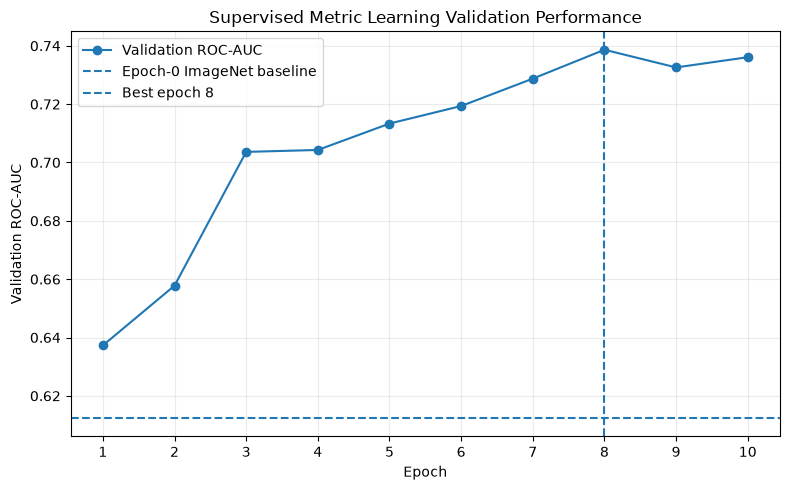

Training curve saved: True
Epoch-0 AUC: 0.612379
Best epoch: 8
Best validation AUC: 0.738648
AUC gain from epoch 0: 0.126269


In [16]:
import matplotlib.pyplot as plt

training_curve_df = (
    training_history_df[
        training_history_df[
            "epoch"
        ] > 0
    ]
    .copy()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    training_curve_df[
        "epoch"
    ],
    training_curve_df[
        "validation_roc_auc"
    ],
    marker="o",
    label="Validation ROC-AUC",
)

ax.axhline(
    epoch0_metrics[
        "roc_auc"
    ],
    linestyle="--",
    label="Epoch-0 ImageNet baseline",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}",
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Validation ROC-AUC"
)

ax.set_title(
    "Supervised Metric Learning Validation Performance"
)

ax.set_xticks(
    training_curve_df[
        "epoch"
    ]
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.tight_layout()

TRAINING_CURVE_PATH = (
    REPORT_DIR
    / "validation_auc_training_curve.png"
)

fig.savefig(
    TRAINING_CURVE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Training curve saved:",
    TRAINING_CURVE_PATH.exists(),
)

print(
    "Epoch-0 AUC:",
    round(
        epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation AUC:",
    round(
        best_validation_auc,
        6,
    ),
)

print(
    "AUC gain from epoch 0:",
    round(
        best_validation_auc
        - epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

## Supervised metric-learning conclusion

This experiment established a verification-oriented supervised metric-learning baseline on QUWI.

A ResNet-18 encoder was initialized from ImageNet weights and trained using a cosine embedding objective. Only layer 4 was optimized, while the earlier backbone and BatchNorm running statistics remained frozen.

Training used 226 development writers. Each writer contributed one genuine Arabic page-1/page-2 pair and one deterministic impostor pair, producing 452 balanced training pairs. Validation and official-test writers remained unseen during training.

### Controlled baseline comparison

Before training, the metric-learning pipeline exactly reproduced the ImageNet writer-disjoint baseline:

- Validation ROC-AUC: 0.6124
- Validation EER: 43.15%

The best metric-learning checkpoint was selected at epoch 8 using validation ROC-AUC only.

The resulting writer-disjoint performance was:

- Validation ROC-AUC: 0.7386
- Validation EER: 32.69%
- Official-test ROC-AUC: 0.7583
- Official-test EER: 31.52%

Compared with the previous classification-trained layer-4 encoder, metric learning improved:

- Validation ROC-AUC by 0.0638
- Validation EER by 3.98 percentage points
- Official-test ROC-AUC by 0.0514
- Official-test EER by 3.63 percentage points

Metric learning improved ROC-AUC in all 12 split-condition comparisons and reduced EER in 11 of 12 comparisons.

### Low-FAR verification

Metric learning also improved true-accept performance at stricter validation operating points.

Compared with the classification-trained representation, validation TAR changed from:

- 32.44% to 35.71% at approximately 10% FAR
- 21.13% to 27.38% at approximately 5% FAR
- 7.74% to 11.01% at approximately 1% FAR
- 0.89% to 3.57% at approximately 0.1% FAR

Despite these improvements, absolute TAR remains low at strict FAR levels. The current metric-learning baseline therefore remains insufficient for practical low-FAR verification.

### Cross-script behavior

Metric learning improved both within-script and cross-script verification, but the gains were not uniform.

On validation writers:

- Within-script macro ROC-AUC increased from 0.7350 to 0.8361
- Cross-script macro ROC-AUC increased from 0.6547 to 0.6999

On official-test writers:

- Within-script macro ROC-AUC increased from 0.7964 to 0.8611
- Cross-script macro ROC-AUC increased from 0.6725 to 0.7214

The within-minus-cross-script AUC gap increased from 0.0803 to 0.1362 on validation and from 0.1238 to 0.1397 on official test.

Therefore, verification-oriented metric learning substantially improves writer discrimination but does not solve script invariance. The representation benefits more strongly in within-script conditions than in cross-script conditions.

### Limitation of the current training protocol

This first metric-learning experiment intentionally used a minimal deterministic training protocol with only one impostor pair per writer. The resulting negative set is therefore sparse and does not expose the model to the full diversity of difficult different-writer comparisons.

The next experiment will introduce writer-aware sampling with richer negative exposure while preserving the same writer-disjoint validation protocol. This will test whether better pair construction can improve verification performance and, importantly, whether it can improve cross-script generalization rather than only within-script discrimination.

In [17]:
metric_summary[
    "training_diagnostics"
] = {
    "epoch0_validation_auc": float(
        epoch0_metrics[
            "roc_auc"
        ]
    ),
    "best_validation_auc": float(
        best_validation_auc
    ),
    "auc_gain_from_epoch0": float(
        best_validation_auc
        - epoch0_metrics[
            "roc_auc"
        ]
    ),
    "total_epochs": int(
        EPOCHS
    ),
    "best_epoch": int(
        best_epoch
    ),
    "total_skipped_optimizer_steps": int(
        training_history_df[
            "skipped_steps"
        ].sum()
    ),
    "training_curve": str(
        TRAINING_CURVE_PATH
    ),
    "checkpoint": str(
        BEST_CHECKPOINT_PATH
    ),
}

metric_summary[
    "cross_script_analysis"
] = {
    "validation_metric_auc_gap": float(
        script_gap_df.loc[
            (
                script_gap_df[
                    "experiment_split"
                ] == "validation"
            )
            & (
                script_gap_df[
                    "training_objective"
                ] == "metric_learning"
            ),
            "within_minus_cross_auc_gap",
        ].iloc[0]
    ),
    "official_test_metric_auc_gap": float(
        script_gap_df.loc[
            (
                script_gap_df[
                    "experiment_split"
                ] == "official_test"
            )
            & (
                script_gap_df[
                    "training_objective"
                ] == "metric_learning"
            ),
            "within_minus_cross_auc_gap",
        ].iloc[0]
    ),
}

with SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metric_summary,
        file,
        indent=2,
    )

print(
    "Summary updated:",
    SUMMARY_PATH.exists(),
)

print(
    "Epoch-0 to best AUC gain:",
    round(
        metric_summary[
            "training_diagnostics"
        ][
            "auc_gain_from_epoch0"
        ],
        6,
    ),
)

print(
    "Validation cross-script gap:",
    round(
        metric_summary[
            "cross_script_analysis"
        ][
            "validation_metric_auc_gap"
        ],
        4,
    ),
)

print(
    "Official-test cross-script gap:",
    round(
        metric_summary[
            "cross_script_analysis"
        ][
            "official_test_metric_auc_gap"
        ],
        4,
    ),
)

print(
    "Skipped optimizer steps:",
    metric_summary[
        "training_diagnostics"
    ][
        "total_skipped_optimizer_steps"
    ],
)

Summary updated: True
Epoch-0 to best AUC gain: 0.126269
Validation cross-script gap: 0.1362
Official-test cross-script gap: 0.1397
Skipped optimizer steps: 0


In [18]:
final_report_paths = [
    TRAINING_HISTORY_PATH,
    CONDITION_RESULTS_PATH,
    AGGREGATE_COMPARISON_PATH,
    CONDITION_COMPARISON_PATH,
    SCRIPT_FAMILY_PATH,
    SCRIPT_GAP_PATH,
    OPERATING_POINT_PATH,
    PAIR_MANIFEST_PATH,
    SUMMARY_PATH,
    TRAINING_CURVE_PATH,
]

for path in final_report_paths:
    print(
        path.name,
        ":",
        path.exists(),
    )

print()
print(
    "Best checkpoint exists:",
    BEST_CHECKPOINT_PATH.exists(),
)

print(
    "Best epoch:",
    best_epoch,
)

print(
    "Validation ROC-AUC:",
    round(
        best_validation_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Validation EER:",
    round(
        best_validation_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Official-test ROC-AUC:",
    round(
        best_test_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Official-test EER:",
    round(
        best_test_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Notebook 11 complete:",
    True,
)

assert all(
    path.exists()
    for path in final_report_paths
)

assert BEST_CHECKPOINT_PATH.exists()
assert best_epoch == 8
assert int(
    training_history_df[
        "skipped_steps"
    ].sum()
) == 0

training_history.csv : True
verification_condition_results.csv : True
classification_metric_comparison.csv : True
condition_comparison.csv : True
script_family_summary.csv : True
script_gap_comparison.csv : True
fixed_far_operating_points.csv : True
training_pair_manifest.csv : True
metric_learning_summary.json : True
validation_auc_training_curve.png : True

Best checkpoint exists: True
Best epoch: 8
Validation ROC-AUC: 0.738648
Validation EER: 32.6948 %
Official-test ROC-AUC: 0.758257
Official-test EER: 31.5199 %
Notebook 11 complete: True
